In [56]:
import pandas as pd
print("Hello, IELE756!")
print(f"pandas version: {pd.__version__}")

Hello, IELE756!
pandas version: 2.2.2


# Tarea 0 --- IELE756
**Team members**: Felipe Velásquez , Matías Moraga



**Region**: Región de Magallanes y la Antártica Chilena


**Date**: 11/03/2026

# **Censo 2024**

1.1 Load


In [36]:
import pandas as pd

ruta = "/content/drive/MyDrive/Colab Notebooks/personas_censo2024.csv"

# Agregamos sep=';' y encoding='latin-1'
persona = pd.read_csv(
    ruta,
    sep=';',
    encoding='latin-1',
    usecols=["region", "comuna", "sexo", "edad", "p27_nacionalidad",
             "p27_nacionalidad_rec", "escolaridad", "sit_fuerza_trabajo"]
)

print("¡Ahora sí cargó!")
persona.head()

¡Ahora sí cargó!


,region,comuna,sexo,edad,p27_nacionalidad,p27_nacionalidad_rec,escolaridad,sit_fuerza_trabajo
0,5,5802,2,80,1,1,17,3.0
1,5,5802,1,52,1,1,14,1.0
2,5,5802,2,45,1,1,12,1.0
3,5,5802,2,8,1,1,2,NaN
4,4,4303,1,69,1,1,12,3.0


Carga de la base de datos Censo 2024 optimizada mediante la selección de columnas específicas desde Google Drive. Se configura el separador y la codificación necesarios para asegurar una lectura correcta de los datos demográficos y regionales.

1.2 Inspect


In [37]:
print(f"Total personas: {len(persona):,}")
print(persona.dtypes)


Total personas: 18,480,432
region                    int64
comuna                    int64
sexo                      int64
edad                      int64
p27_nacionalidad          int64
p27_nacionalidad_rec      int64
escolaridad               int64
sit_fuerza_trabajo      float64
dtype: object


In [38]:
print(persona.shape)
persona.head(10)

(18480432, 8)


,region,comuna,sexo,edad,p27_nacionalidad,p27_nacionalidad_rec,escolaridad,sit_fuerza_trabajo
0,5,5802,2,80,1,1,17,3.0
1,5,5802,1,52,1,1,14,1.0
2,5,5802,2,45,1,1,12,1.0
3,5,5802,2,8,1,1,2,NaN
4,4,4303,1,69,1,1,12,3.0
5,4,4303,2,65,1,1,12,3.0
6,4,4303,1,58,1,1,15,1.0
7,11,11202,2,-66,-66,1,8,1.0
8,11,11202,1,-66,-66,1,5,1.0
9,11,11202,1,-66,-66,1,3,NaN


In [39]:
persona.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18480432 entries, 0 to 18480431
Data columns (total 8 columns):
 #   Column                Dtype  
---  ------                -----  
 0   region                int64  
 1   comuna                int64  
 2   sexo                  int64  
 3   edad                  int64  
 4   p27_nacionalidad      int64  
 5   p27_nacionalidad_rec  int64  
 6   escolaridad           int64  
 7   sit_fuerza_trabajo    float64
dtypes: float64(1), int64(7)
memory usage: 1.1 GB


Exploración inicial de la estructura del dataset mediante el conteo de registros, verificación de tipos de datos y dimensiones. Se utiliza info() y head() para validar la integridad de la carga y el consumo de memoria de la base de datos.

1.3 Filter to your region

In [40]:
# region es numérico en el Censo
Magallanes = persona[persona["region"] == 2]
print(f"Magallanes: {len(Magallanes):,} personas")

Magallanes: 635,416 personas



Filtrado del dataset mediante el código numérico de región para obtener un subconjunto específico de la población. Se contabiliza el total de registros resultantes para focalizar el análisis demográfico a nivel regional.

1.4 First look at nationality


In [41]:
# Códigos: 1=Chileno, 2=Chileno+otra, 3=Extranjero, -99=NR
print(Magallanes["p27_nacionalidad"].value_counts())

p27_nacionalidad
 1     498467
 3     118611
 2       7152
-66      6562
-99      4624
Name: count, dtype: int64


In [42]:
# Variable recodificada (más conveniente)
print(Magallanes["p27_nacionalidad_rec"].value_counts())
foreign = Magallanes["p27_nacionalidad_rec"] \
.value_counts(normalize=True)
print(f"% extranjeros: {foreign.get('Extranjero', 0):.1%}")

p27_nacionalidad_rec
 1     510932
 2     119832
-99      4652
Name: count, dtype: int64
% extranjeros: 0.0%


Análisis de la distribución de nacionalidad mediante el recuento de categorías originales y variables recodificadas. Incluye el cálculo del porcentaje de población extranjera para caracterizar la composición demográfica de la región.

# **ENO - Enfermedades de Notificación Obligatoria**

2.1 Load


In [44]:
ruta_eno = "/content/drive/MyDrive/Colab Notebooks/20241218_base_eno_final.csv"

# Cambiamos a encoding="utf-8-sig" para arreglar los acentos y el inicio de columna
eno = pd.read_csv(
    ruta_eno,
    sep=";",
    encoding="utf-8-sig",
    low_memory=False
)

# Esto debería mostrar los nombres y datos correctamente ahora
print(f"Total: {len(eno):,}")
print(eno.columns.tolist())

Total: 333,300
['etapa_clinica', 'region', 'seremi', 'nacionalidad', 'cie_10_diagnostico', 'diagnostico', 'Autóctono', 'anho_notificacion', 'ENO', 'pueblo_indigena', 'nombre_instruccion', 'presenta_sintomas', 'sintomas', 'consumo_agua_no_potable', 'antecedente_teniasis', 'imagenologia', 'manifestaciones', 'existe_coinfeccion', 'via_transmision', 'n_parejas_sexuales', 'uso_preservativo', 'pais_contagio', 'paciente_inmunosuprimido', 'vih', 'pareja', 'exantema_mpox', 'factores_exposicion', 'neumonia', 'contacto_aves', 'genotipo_1', 'recuento_linfocitos', 'clasificacion_final_vih', 'etapa_vih_sida', 'hospitalizacion', 'nombre_primer_sintoma', 'SeroGrupo', 'sexo', 'grupo_edad', 'codigo_comuna_residencia']


In [45]:
eno.head()

,etapa_clinica,region,seremi,nacionalidad,cie_10_diagnostico,diagnostico,Autóctono,anho_notificacion,ENO,pueblo_indigena,...,genotipo_1,recuento_linfocitos,clasificacion_final_vih,etapa_vih_sida,hospitalizacion,nombre_primer_sintoma,SeroGrupo,sexo,grupo_edad,codigo_comuna_residencia
0,CONFIRMADA,Región de Tarapacá,TARAPACÁ,Extranjero,A97.0,DENGUE SIN DATOS DE ALARMA,No,2020,Arbovirus,Desconocido,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,mujer,25-29,01107
1,CONFIRMADA,Región de Valparaíso,VALPARAÍSO,Desconocido,A90.X,FIEBRE DEL DENGUE,No,2018,Arbovirus,Desconocido,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,hombre,70-74,05301
2,CONFIRMADA,Región de Valparaíso,VALPARAÍSO,Chile,A97.0,DENGUE SIN DATOS DE ALARMA,No,2020,Arbovirus,Desconocido,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,mujer,70-74,05109
3,CONFIRMADA,Región de Valparaíso,VALPARAÍSO,Extranjero,A97.0,DENGUE SIN DATOS DE ALARMA,No,2019,Arbovirus,Desconocido,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,hombre,40-44,05301
4,CONFIRMADA,Región de Valparaíso,VALPARAÍSO,Chile,A97.0,DENGUE SIN DATOS DE ALARMA,No,2021,Arbovirus,Desconocido,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,hombre,60-64,05109



Carga de la base de datos de Enfermedades de Notificación Obligatoria (ENO) desde Google Drive, aplicando codificación UTF-8 para asegurar la correcta lectura de acentos. Se valida la operación mediante el conteo total de registros y la inspección de las primeras filas del dataset.

2.2 Filter to your region


In [46]:
# Para ver solo los nombres de las regiones únicas
regiones_unicas = eno['region'].unique()
print(regiones_unicas)

['Región de Tarapacá' 'Región de Valparaíso'
 'Región Metropolitana de Santiago' 'Región de Los Lagos'
 'Región de Arica y Parinacota' 'Región del Biobío' 'Región de Los Ríos'
 'Región de Antofagasta' 'Región de la Araucanía'
 'Región del Libertador General Bernardo OHiggins'
 'Región de Aysén del General Carlos Ibáñez del Campo' 'Región del Ñuble'
 'Región del Maule' 'Región de Atacama' 'Región de Coquimbo'
 'Región de Magallanes y la Antártica Chilena' 'Desconocido']


In [47]:
eno_tar = eno[eno["region"] == "Región de Magallanes y la Antártica Chilena"]
print(f"Magallanes: {len(eno_tar):,}")

Magallanes: 3,208



Identificación de regiones únicas en la base de datos ENO y filtrado por la Región de Magallanes. Se cuantifica el total de casos locales para focalizar el análisis epidemiológico regional.

2.3 Notifications by year

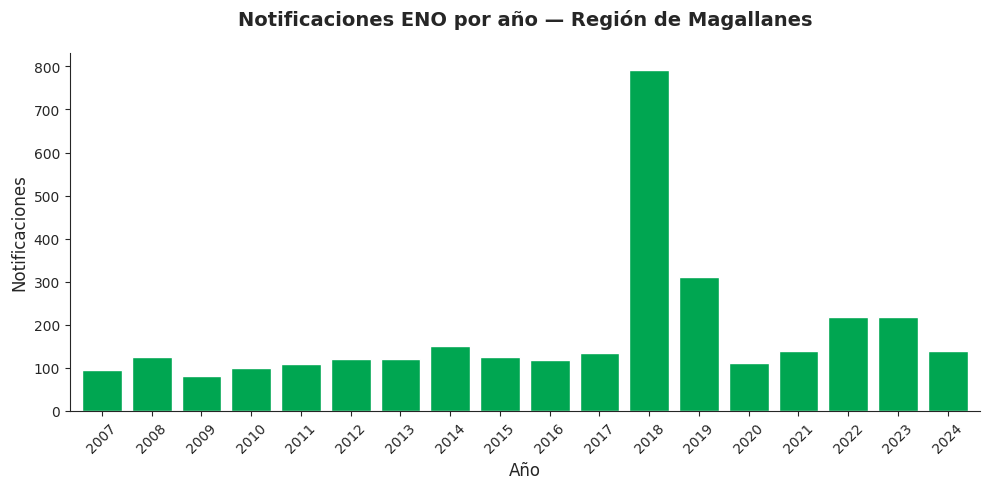

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filtramos los datos para Magallanes
# Nota: Verificamos que el nombre sea exacto como aparece en tus datos
df_mag = eno[eno['region'].str.contains("Magallanes", na=False)]

# Configuraciones de estilo global
color_verde = "#00a651" # El verde de tus imágenes
sns.set_style("ticks")

# --- GRÁFICO 1: Notificaciones por Año ---
plt.figure(figsize=(10, 5))
datos_anho = df_mag['anho_notificacion'].value_counts().sort_index()

ax1 = datos_anho.plot(kind='bar', color=color_verde, width=0.8)

plt.title("Notificaciones ENO por año — Región de Magallanes", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Año", fontsize=12)
plt.ylabel("Notificaciones", fontsize=12)
plt.xticks(rotation=45)

# Quitar bordes superior y derecho
sns.despine()
plt.tight_layout()
plt.show()

Visualización de la evolución temporal de las notificaciones ENO en Magallanes entre 2007 y 2024. Permite identificar tendencias de salud pública y picos históricos de incidencia mediante un gráfico de barras.

2.4 Top 5 diseases

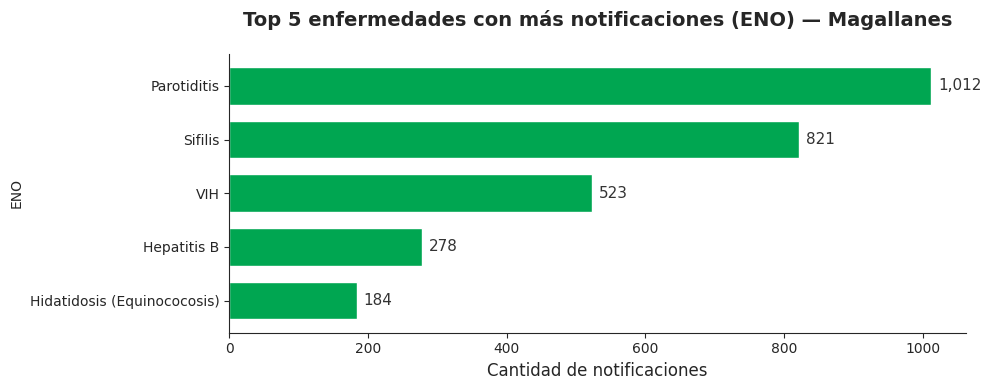

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filtramos la base ENO para la región de Magallanes
# (Usamos .str.contains por seguridad con los nombres largos)
eno_region = eno[eno['region'].str.contains("Magallanes", na=False)].copy()

# 2. Calculamos las 5 enfermedades con más notificaciones (columna "ENO")
top_5_diseases = eno_region["ENO"].value_counts().head(5)

# 3. Configuramos el estilo y el color verde
plt.figure(figsize=(10, 4))
color_verde = "#00a651"
sns.set_style("ticks")

# 4. Creamos el gráfico de barras horizontales
ax = top_5_diseases.plot(kind='barh', color=color_verde, width=0.7)

# Títulos y etiquetas
plt.title("Top 5 enfermedades con más notificaciones (ENO) — Magallanes",
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Cantidad de notificaciones", fontsize=12)
plt.gca().invert_yaxis() # Para que la más frecuente esté arriba

# Agregamos los números al final de cada barra
for i, v in enumerate(top_5_diseases):
    ax.text(v + (max(top_5_diseases)*0.01), i, f'{int(v):,}',
            va='center', fontsize=11, color='#333')

# Limpiamos el diseño
sns.despine()
plt.tight_layout()

# Mostramos el gráfico
plt.show()


Generación de un gráfico de barras horizontales para identificar las 5 enfermedades con mayor frecuencia de notificación en Magallanes. Incluye el filtrado regional de datos ENO, cálculo de frecuencias y personalización estética para destacar las principales prioridades sanitarias locales.

2.5 Nationality distribution

In [51]:
eno_tar["nacionalidad"].value_counts()

,count
nacionalidad,
Desconocido,1587
Chile,1215
Extranjero,406


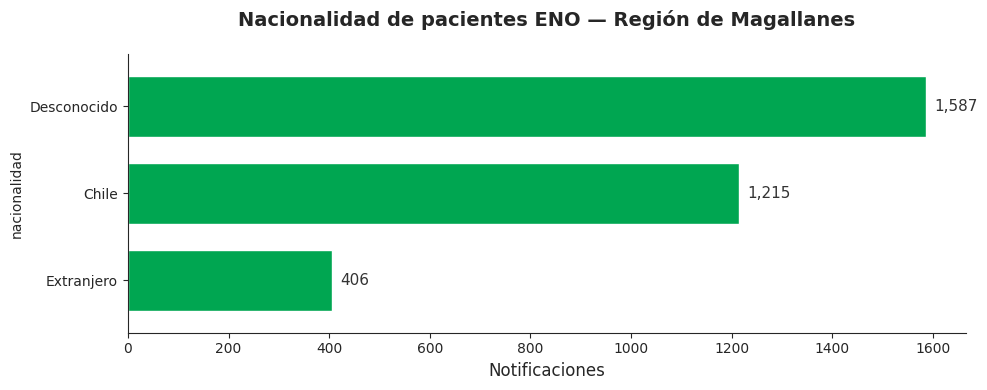

In [52]:
plt.figure(figsize=(10, 4))
# Contamos nacionalidades y ordenamos de mayor a menor
datos_nac = df_mag['nacionalidad'].value_counts()

ax2 = datos_nac.plot(kind='barh', color=color_verde, width=0.7)

plt.title("Nacionalidad de pacientes ENO — Región de Magallanes", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Notificaciones", fontsize=12)
plt.gca().invert_yaxis() # Para que el más grande salga arriba

# Agregar etiquetas de números al final de las barras
for i, v in enumerate(datos_nac):
    ax2.text(v + (max(datos_nac)*0.01), i, f'{v:,}', color='#333', va='center', fontsize=11)

sns.despine()
plt.tight_layout()
plt.show()


Análisis y visualización de la distribución por nacionalidad de los pacientes en Magallanes. Se utiliza un gráfico de barras para comparar la frecuencia de notificaciones según el origen, permitiendo caracterizar demográficamente los registros epidemiológicos locales.

¿Cuál es la enfermedad más común en Magallanes para extranjeros?

In [53]:
eno_tar[eno_tar["nacionalidad"] == "Extranjero"] \
["ENO"].value_counts().head()

,count
ENO,
Hepatitis B,205
VIH,87
Sifilis,62
Parotiditis,12
Infección gonocócica,12


¿Cuántas comunas únicas hay en ENO Magallanes?

In [54]:
eno_tar["codigo_comuna_residencia"].nunique()

34

# **GRD — Hospital Discharges**

3.1 Load one year

In [7]:
import pandas as pd
import zipfile

# 1. Definimos la lista de columnas que pediste
cols = [
    "GLOSA_COMUNA_RESIDENCIA",
    "GLOSA_PAIS_ORIGEN",
    "GLOSA_REGION_RESIDENCIA",
    "SEXO",
    "DIAG1",
    "ANO_EGRESO",
    "DIAS_ESTADA"
]

# 2. Ruta de tu archivo en Google Drive
ruta_zip = "/content/drive/MyDrive/Colab Notebooks/EGRESOS_2024.zip"

# 3. Abrir el ZIP y leer el archivo CSV
with zipfile.ZipFile(ruta_zip) as z:
    # Abrimos el archivo que está dentro del ZIP (asegúrate que el nombre sea este)
    with z.open("EGRESOS_2024.csv") as f:
        grd = pd.read_csv(
            f,
            sep=";",              # Separador punto y coma
            usecols=cols,         # Solo las columnas de tu lista
            encoding="latin-1",   # Codificación habitual para estos archivos
            low_memory=False
        )

# 4. Verificamos que cargó correctamente
print(f"Total registros cargados: {len(grd):,}")
print("Columnas actuales:", grd.columns.tolist())
grd.head()

Total registros cargados: 1,667,349
Columnas actuales: ['SEXO', 'GLOSA_PAIS_ORIGEN', 'GLOSA_COMUNA_RESIDENCIA', 'GLOSA_REGION_RESIDENCIA', 'ANO_EGRESO', 'DIAG1', 'DIAS_ESTADA']


,SEXO,GLOSA_PAIS_ORIGEN,GLOSA_COMUNA_RESIDENCIA,GLOSA_REGION_RESIDENCIA,ANO_EGRESO,DIAG1,DIAS_ESTADA
0,2,Argentina,Iquique,De Tarapacá,2024,N908,2
1,2,Argentina,Iquique,De Tarapacá,2024,O680,4
2,2,Argentina,Iquique,De Tarapacá,2024,O757,2
3,2,Argentina,Iquique,De Tarapacá,2024,N800,2
4,2,Argentina,Iquique,De Tarapacá,2024,O601,3



Carga y extracción de la base de datos de egresos hospitalarios 2024 desde un archivo comprimido en Drive. Se seleccionan columnas estratégicas para optimizar el uso de memoria y se valida la integridad de la carga mediante el conteo de registros.

In [17]:
# 1. Ver la lista de regiones únicas
regiones = grd['GLOSA_REGION_RESIDENCIA'].unique()
print("Regiones encontradas:")
print(regiones)

# 2. (Recomendado) Ver cuántas veces aparece cada región (conteo)
print("\nCantidad de registros por región:")
print(grd['GLOSA_REGION_RESIDENCIA'].value_counts())

Regiones encontradas:
['De Tarapacá' 'De Antofagasta' 'De Atacama' 'De Coquimbo' 'De Valparaíso'
 "Del Libertador B. O'Higgins" 'Del Maule' 'Del Bíobío' 'De La Araucanía'
 'De Los Lagos' 'De Aisén del Gral. C. Ibáñez del Campo'
 'De Magallanes y de La Antártica Chilena' 'Metropolitana de Santiago'
 'De Los Ríos' 'De Arica y Parinacota' 'De Ñuble' 'Extranjero' 'Ignorada'
 '*']

Cantidad de registros por región:
GLOSA_REGION_RESIDENCIA
Metropolitana de Santiago                  648390
De Valparaíso                              166279
Del Bíobío                                 166268
De La Araucanía                             92569
Del Maule                                   89879
De Los Lagos                                84604
Del Libertador B. O'Higgins                 75579
De Antofagasta                              57800
De Coquimbo                                 56230
De Ñuble                                    45322
De Los Ríos                                 40499
De Tarapacá 

3.2 Filter to your region


In [31]:
# 3.2 Filtrar a tu región (Magallanes)
mi_region = "De Magallanes y de La Antártica Chilena"

# Filtramos
grd_region = grd[grd['GLOSA_REGION_RESIDENCIA'] == mi_region].copy()

# Contamos la cantidad de gente egresada (Discharges)
total_egresos = len(grd_region)

print(f"Discharges in my region (Total de egresados en Magallanes): {total_egresos:,}")

Discharges in my region (Total de egresados en Magallanes): 8,807


Filtrado de la base de egresos hospitalarios para extraer únicamente los registros de la Región de Magallanes. Se contabiliza el total de pacientes egresados localmente para focalizar el análisis estadístico en la zona de estudio.

3.3 Join with CIE-10

In [29]:
import pandas as pd
import zipfile

# 1. Cargamos el diccionario
with zipfile.ZipFile(ruta_zip) as z:
    with z.open("Diccionario BD egresos hospitalario.xlsx") as f:
        cie10 = pd.read_excel(f, sheet_name="codigo CIE-10", header=8)

# Limpiamos nombres de columnas
cie10.columns = cie10.columns.str.strip()

# --- SOLUCIÓN AL ERROR ---
# Si las columnas ya existen en 'grd' por una ejecución anterior, las borramos para evitar duplicados
columnas_a_borrar = ["CODIGO SUBCATEGORIA", "GLOSA CATEGORIA"]
grd = grd.drop(columns=[c for c in columnas_a_borrar if c in grd.columns])

# 2. Preparamos el diccionario con solo lo que necesitas
# Renombramos "CODIGO SUBCATEGORIA" a "DIAG1" para que se unan perfectamente
cie10_clean = cie10[["CODIGO SUBCATEGORIA", "GLOSA CATEGORIA"]].rename(
    columns={"CODIGO SUBCATEGORIA": "DIAG1"}
)

# 3. Realizamos la unión (Merge) usando la columna común "DIAG1"
grd = grd.merge(cie10_clean, on="DIAG1", how="left")

# 4. Verificamos el resultado
print("Unión completada exitosamente.")
display(grd[["DIAG1", "GLOSA CATEGORIA"]].head())

Unión completada exitosamente.


,DIAG1,GLOSA CATEGORIA
0,N908,Otros trastornos no inflamatorios de la vulva ...
1,O680,Trabajo de parto y parto complicados por sufri...
2,O757,Otras complicaciones del trabajo de parto y de...
3,N800,Endometriosis
4,O601,Parto prematuro


Integración del diccionario médico CIE-10 mediante una operación de unión (merge) para asociar descripciones clínicas a los códigos de diagnóstico. Incluye limpieza de encabezados y gestión de duplicados para garantizar la integridad de la base de datos resultante.

3.4 Top 5 diagnoses

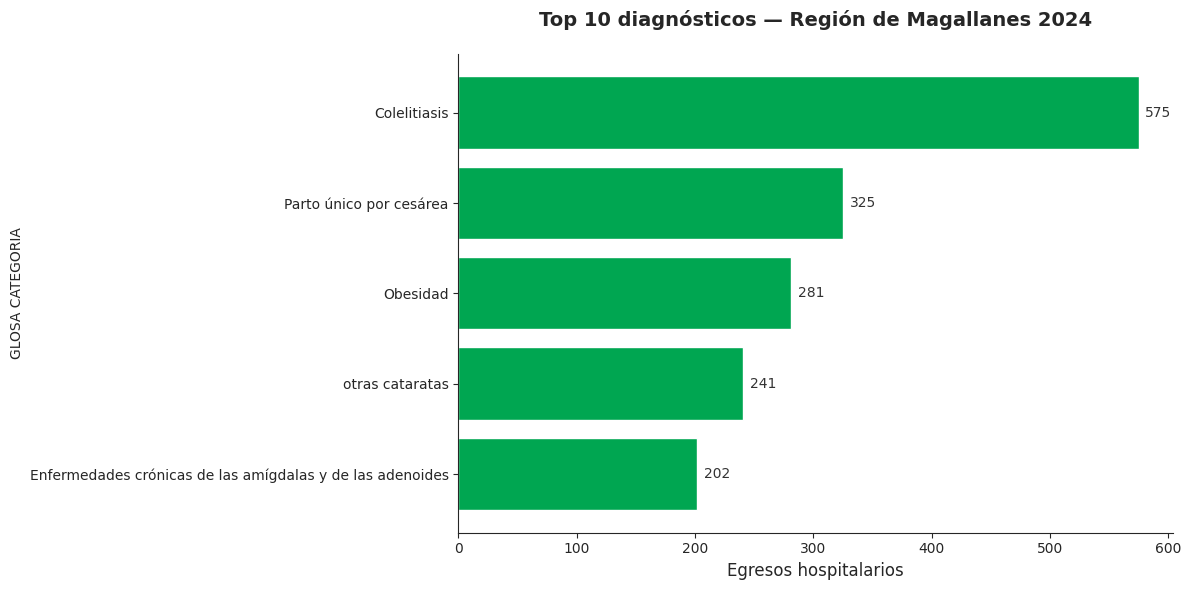

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculamos los 10 diagnósticos más comunes
# Usamos la columna "Descripción" que creamos en el paso anterior
top_10_diag = grd_region["GLOSA CATEGORIA"].value_counts().head(5)

# 2. Configuramos el estilo del gráfico
plt.figure(figsize=(12, 6))
color_verde = "#00a651" # Verde institucional
sns.set_style("ticks")

# 3. Creamos el gráfico de barras horizontales (barh)
ax = top_10_diag.plot(kind='barh', color=color_verde, width=0.8)

# Configuramos títulos y etiquetas
plt.title("Top 10 diagnósticos — Región de Magallanes 2024", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Egresos hospitalarios", fontsize=12)
plt.gca().invert_yaxis() # Para que el más frecuente aparezca arriba

# 4. Agregamos los números exactos al final de cada barra
for i, v in enumerate(top_10_diag):
    ax.text(v + (max(top_10_diag)*0.01), i, f'{int(v):,}',
            va='center', fontsize=10, color='#333')

# Limpiamos el diseño (quitamos bordes innecesarios)
sns.despine()
plt.tight_layout()

# Mostramos el gráfico
plt.show()

Visualización de los diagnósticos más frecuentes en la Región de Magallanes mediante un gráfico de barras horizontales. El análisis identifica las principales causas de egreso hospitalario, facilitando la interpretación epidemiológica local con etiquetas de frecuencia directa.